## Can a simple neural network learn the function $z^2=x^2+y^2$ outside the bounds of it's training data, or within different parts of it's training data

### Importing data and packages

In [33]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [34]:
training_data = pd.read_csv('raw_data_v2.csv')
training_data = training_data[['X','Z','Y']]

### Train test split

In [35]:
length = len(training_data)

split_idx = int(length*0.8)
train_df, test_df = training_data.iloc[0:split_idx],training_data.iloc[split_idx:]

### Initializing our neural network for training

In [36]:
device = torch.device("mps" if torch.mps.is_available() else "cpu")
X, Y = torch.tensor(train_df[['X','Z']].to_numpy(), dtype=torch.float32), torch.tensor(train_df['Y'].to_numpy(), dtype=torch.float32)
loader = DataLoader(TensorDataset(X,Y), batch_size=20, shuffle=True)

In [37]:
class nikkisfirstMLP(nn.Module):
    def __init__(self, d_in:int, d_hidden:int, d_out:int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, d_hidden),
            nn.ReLU(),
            nn.Linear(d_hidden, d_hidden),
            nn.ReLU(),
            nn.Linear(d_hidden, d_out)
            )
        
    def forward(self, x):
        return self.net(x)


### Training loop 

In [38]:
model = nikkisfirstMLP(d_in=2,d_hidden=10,d_out=1).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(),lr=1e-3)


for epoch in range(10):
    model.train()
    total_loss = 0

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(xb).squeeze(1)
        loss = criterion(out,yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()*xb.size(0)

    print(f"epoch {epoch+1}: loss={total_loss:.4f}")

KeyboardInterrupt: 

### Validation set output

In [ ]:
test_features = torch.tensor(test_df[['X','Z']].to_numpy(), dtype=torch.float32)
test_Y = torch.tensor(test_df['Y'].to_numpy(), dtype=torch.float32)

model.eval()
with torch.no_grad():
    preds = model(test_features.to(device)).squeeze(1).cpu().numpy()

output_df = pd.DataFrame({
    'X': test_df['X'].to_numpy(),
    'Z': test_df['Z'].to_numpy(),
    'Y_true': test_Y.numpy(),
    'Y_pred': preds,
})

MSE on validation set:  323818.84375


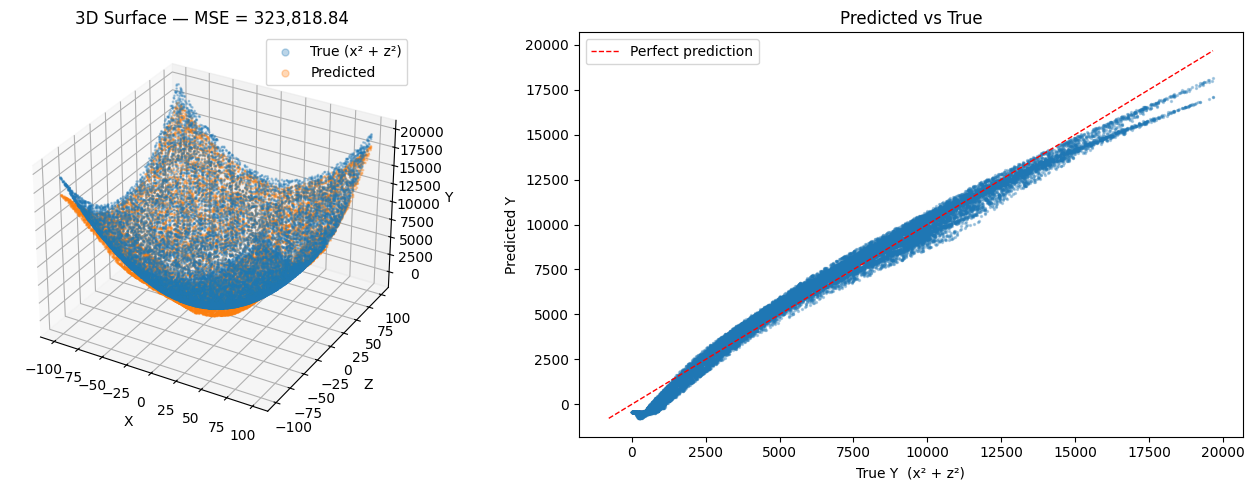

In [ ]:
val_mse = criterion(torch.tensor(preds), test_Y).item()
print("MSE on validation set: ", val_mse)

fig = plt.figure(figsize=(14, 5))

ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.scatter(output_df['X'], output_df['Z'], output_df['Y_true'],
            s=1, alpha=0.3, label='True (x² + z²)')
ax1.scatter(output_df['X'], output_df['Z'], output_df['Y_pred'],
            s=1, alpha=0.3, label='Predicted')
ax1.set_xlabel('X')
ax1.set_ylabel('Z')
ax1.set_zlabel('Y')
ax1.set_title(f'3D Surface — MSE = {val_mse:,.2f}')
ax1.legend(markerscale=5)

ax2 = fig.add_subplot(1, 2, 2)
ax2.scatter(output_df['Y_true'], output_df['Y_pred'], s=2, alpha=0.3)
lims = [min(output_df['Y_true'].min(), output_df['Y_pred'].min()),
        max(output_df['Y_true'].max(), output_df['Y_pred'].max())]
ax2.plot(lims, lims, 'r--', linewidth=1, label='Perfect prediction')
ax2.set_xlabel('True Y  (x² + z²)')
ax2.set_ylabel('Predicted Y')
ax2.set_title('Predicted vs True')
ax2.legend()

plt.tight_layout()
plt.show()

### How does the trained model generalize for data not in the range of generated training data from creating_data_v2.py

In [ ]:
from creating_data_v2 import X_MIN, X_MAX, Y_MIN, Y_MAX, NOISE

BANDS = [
    (abs(X_MAX),       500),
    (500,             1_000),
    (1_000,           5_000),
    (5_000,          10_000),
    (10_000,         50_000),
    (50_000,        100_000),
]

N_PER_BAND = 2_000
band_results = []

def eval_band(lo, hi):
    """Generate OOS data where |X| and |Z| ∈ [lo, hi], predict, compute & plot MSE."""
    abs_x = np.random.uniform(lo, hi, size=N_PER_BAND)
    abs_z = np.random.uniform(lo, hi, size=N_PER_BAND)
    signs_x = np.random.choice([-1, 1], size=N_PER_BAND)
    signs_z = np.random.choice([-1, 1], size=N_PER_BAND)
    xs = abs_x * signs_x
    zs = abs_z * signs_z
    ys_true = xs ** 2 + zs ** 2

    model.eval()
    with torch.no_grad():
        features = torch.tensor(np.column_stack([xs, zs]), dtype=torch.float32).to(device)
        preds = model(features).squeeze(1).cpu().numpy()

    mse = float(np.mean((preds - ys_true) ** 2))
    band_results.append((lo, hi, mse))

    fig = plt.figure(figsize=(14, 5))

    ax1 = fig.add_subplot(1, 2, 1, projection='3d')
    ax1.scatter(xs, zs, ys_true, s=2, alpha=0.3, label='True (x² + z²)')
    ax1.scatter(xs, zs, preds, s=2, alpha=0.3, label='Predicted')
    ax1.set_xlabel('X')
    ax1.set_ylabel('Z')
    ax1.set_zlabel('Y')
    ax1.set_title(f'|X|,|Z| ∈ [{lo:,.0f}, {hi:,.0f}]')
    ax1.legend(markerscale=5)

    ax2 = fig.add_subplot(1, 2, 2)
    ax2.scatter(ys_true, preds, s=4, alpha=0.4)
    plot_lims = [min(ys_true.min(), preds.min()), max(ys_true.max(), preds.max())]
    ax2.plot(plot_lims, plot_lims, 'r--', linewidth=1, label='Perfect prediction')
    ax2.set_title(f'MSE = {mse:,.2f}')
    ax2.set_xlabel('True Y  (x² + z²)')
    ax2.set_ylabel('Predicted Y')
    ax2.legend()

    plt.tight_layout()
    plt.show()

    return mse

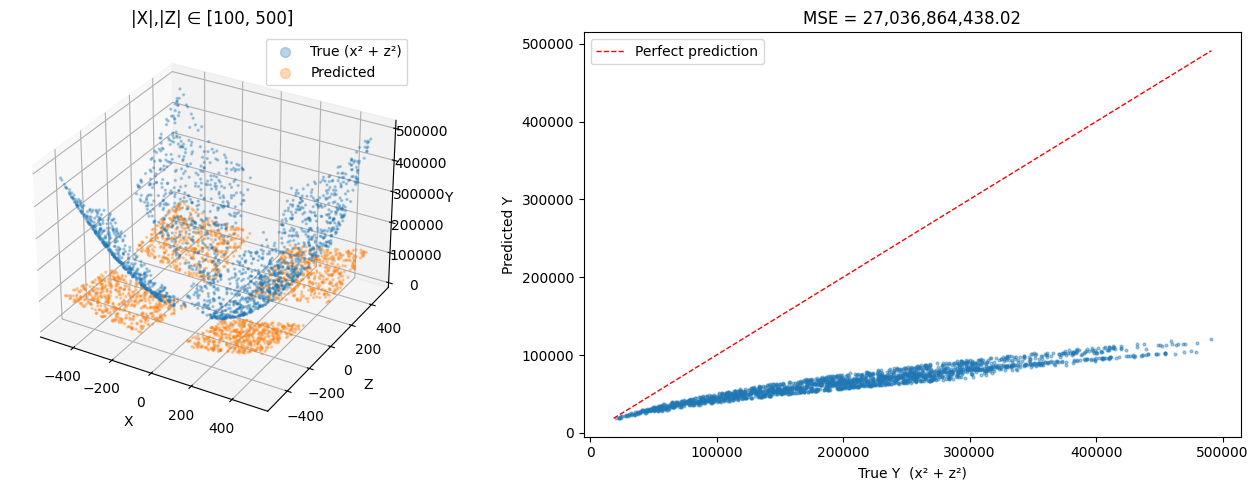

27036864438.017593

In [ ]:
eval_band(*BANDS[0])

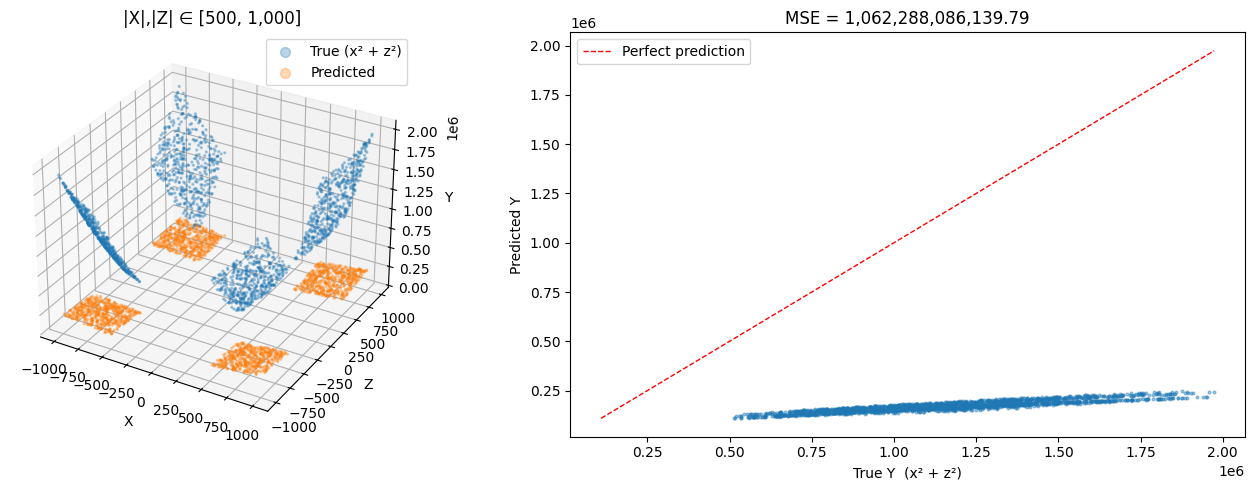

1062288086139.7913

In [ ]:
eval_band(*BANDS[1])

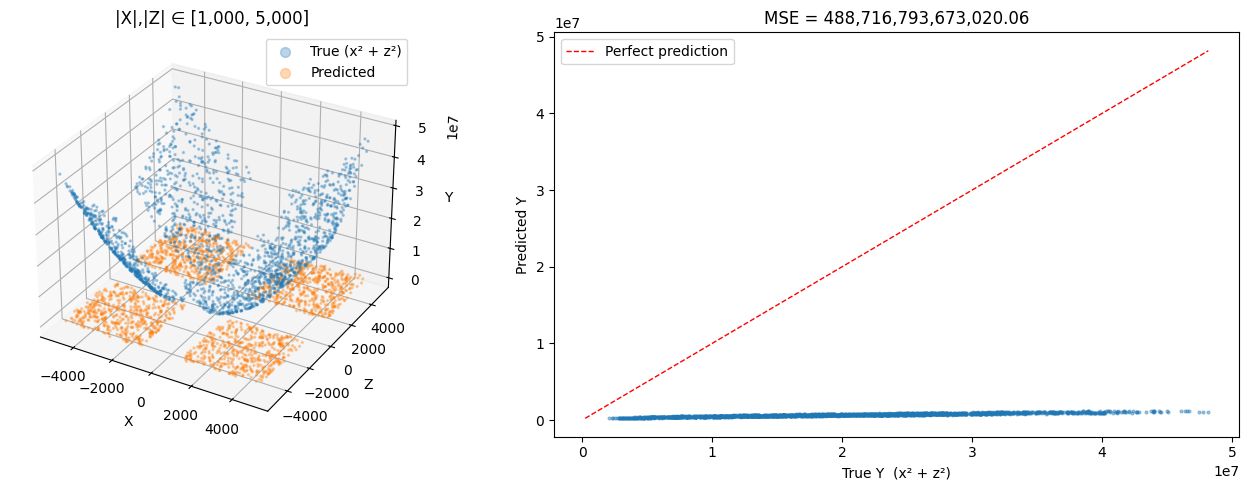

488716793673020.06

In [ ]:
eval_band(*BANDS[2])

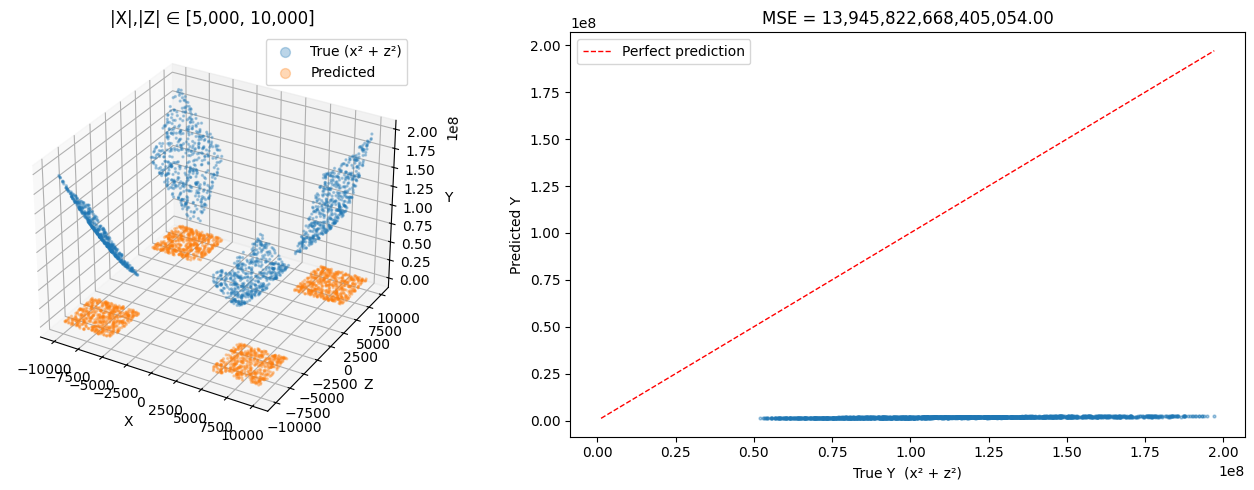

1.3945822668405054e+16

In [ ]:
eval_band(*BANDS[3])

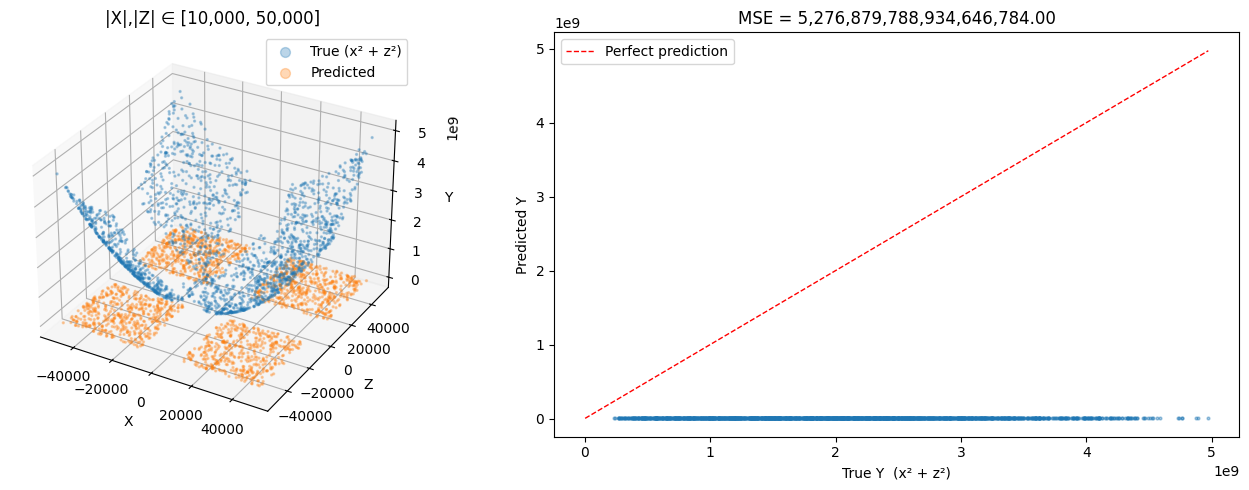

5.276879788934647e+18

In [ ]:
eval_band(*BANDS[4])

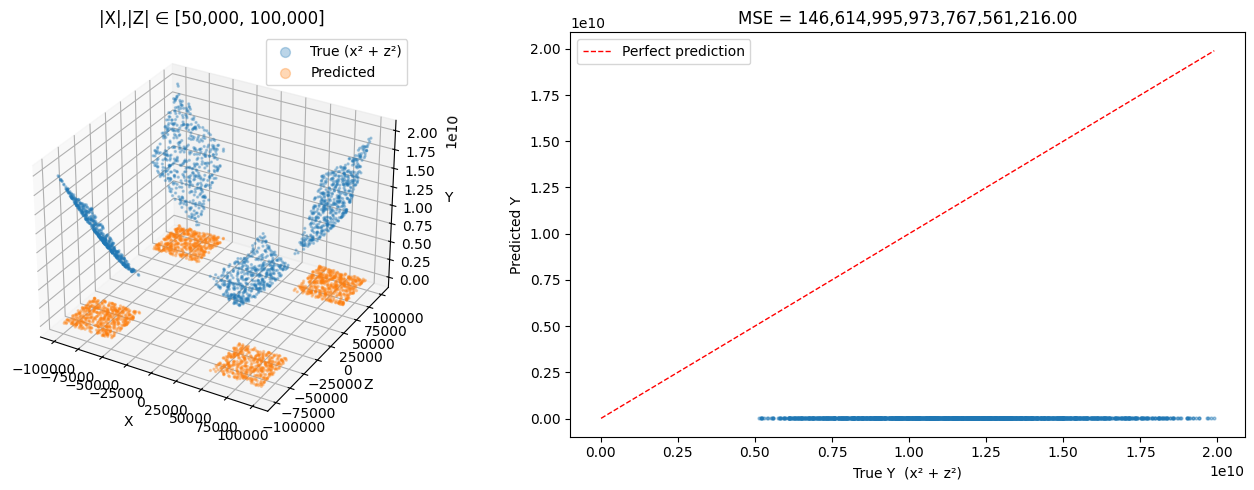

1.4661499597376756e+20

In [ ]:
eval_band(*BANDS[5])

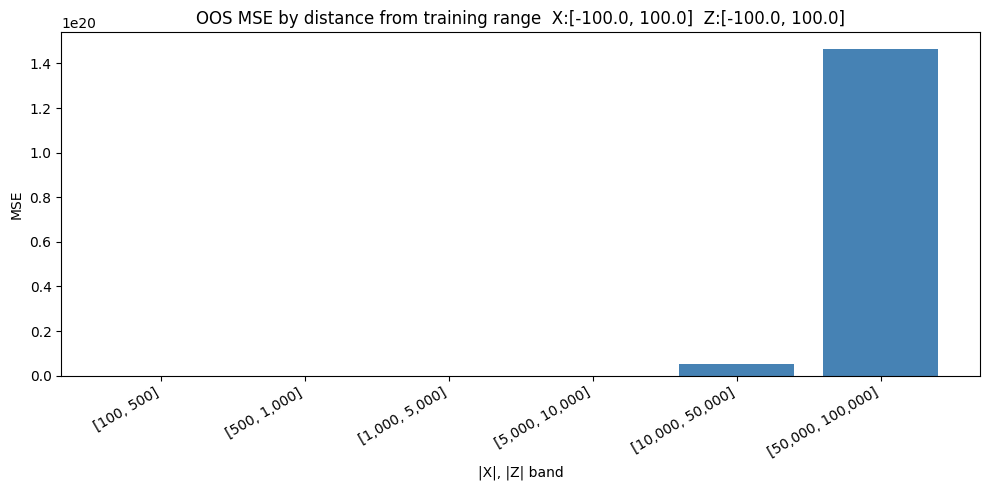

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
labels = [f"[{lo:,.0f}, {hi:,.0f}]" for lo, hi, _ in band_results]
mses   = [m for _, _, m in band_results]

ax.bar(range(len(mses)), mses, color="steelblue")
ax.set_xticks(range(len(mses)))
ax.set_xticklabels(labels, rotation=30, ha="right")
ax.set_ylabel("MSE")
ax.set_xlabel("|X|, |Z| band")
ax.set_title(f"OOS MSE by distance from training range  X:[{X_MIN}, {X_MAX}]  Z:[{Y_MIN}, {Y_MAX}]")
ax.ticklabel_format(axis="y", style="scientific", scilimits=(0, 0))
plt.tight_layout()
plt.show()